In [ ]:
import zipfile
import os

zip_file_path = '/content/archive (21).zip'
 # Make sure this path is correct
extract_path = '/content/extracted_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

# Verify the contents (optional)
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Dataset extracted to: /content/extracted_dataset
Contents of the extracted directory:
extracted_dataset/
    no/
        no 99.jpg
        29 no.jpg
        20 no.jpg
        N17.jpg
        39 no.jpg
        No15.jpg
        15 no.jpg
        8 no.jpg
        no 923.jpg
        no 4.jpg
        No16.jpg
        4 no.jpg
        6 no.jpg
        no 89.jpg
        N26.JPG
        49 no.jpg
        24 no.jpg
        31 no.jpg
        28 no.jpg
        No22.jpg
        33 no.jpg
        45 no.jpg
        no 92.jpg
        22 no.jpg
        41 no.jpg
        no 96.jpg
        no 3.jpg
        N16.jpg
        N22.JPG
        46 no.jpg
        no 9.png
        No13.jpg
        40 no.jpg
        42 no.jpg
        no 98.jpg
        18 no.jpg
        no 90.jpg
        10 no.jpg
        48 no.jpeg
        23 no.jpg
        19 no.jpg
        43 no.jpg
        14 no.jpg
        36 no.jpg
        No12.jpg
        30 no.jpg
        13 no.jpg
        34 no.jpg
        no 100.jpg
        no 97.jpg
   

## CNN Model for Image Classification

This section sets up and trains a Convolutional Neural Network (CNN) to classify images from the `extracted_dataset`. The dataset contains `yes` and `no` categories, indicating a binary classification task. The model will be built using TensorFlow and Keras.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# Define paths and parameters
data_dir = '/content/extracted_dataset/brain_tumor_dataset' # Corrected path
img_height = 180  # Standardize image height
img_width = 180   # Standardize image width
batch_size = 32   # Number of images per batch

In [ ]:
# Load the dataset and split into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.


In [ ]:
# Display class names found by the dataset loader
class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Configure the dataset for performance
# Use buffered prefetching to load images from disk without I/O blocking
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Class names: ['no', 'yes']


In [ ]:
# Define the CNN model architecture
num_classes = len(class_names)

model = keras.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Softmax for multi-class, or sigmoid for binary
])

# Adjust the output layer and loss function for binary classification (2 classes)
# The `image_dataset_from_directory` automatically encodes labels as integers.
# If num_classes is 2, `sparse_categorical_crossentropy` is fine, or `binary_crossentropy` with `Dense(1, activation='sigmoid')`.
# Given the current setup with `softmax` and `num_classes`, `sparse_categorical_crossentropy` is appropriate.
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Display the model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,234 (25.36 MB)

 Trainable params: 6,647,234 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
epochs = 10 # You can adjust the number of epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6847 - loss: 0.6747 - val_accuracy: 0.8200 - val_loss: 0.5222
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8079 - loss: 0.4816 - val_accuracy: 0.7400 - val_loss: 0.5466
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8276 - loss: 0.4016 - val_accuracy: 0.8200 - val_loss: 0.5162
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8867 - loss: 0.3074 - val_accuracy: 0.8000 - val_loss: 0.4958
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9360 - loss: 0.1966 - val_accuracy: 0.8400 - val_loss: 0.4541
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9606 - loss: 0.1100 - val_accuracy: 0.8200 - val_loss: 0.4149
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9951 - loss: 0.0549 - val_accuracy: 0.8200 - val_loss: 0.5869
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9951 - loss: 0.0355 - val_accuracy: 0.8800 - val_loss: 0.3056
Epoch 9/

In [ ]:
# Evaluate the model
print("\nEvaluating the model on the validation set:")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


Evaluating the model on the validation set:
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.8200 - loss: 0.8407
Validation Loss: 0.8407
Validation Accuracy: 0.8200


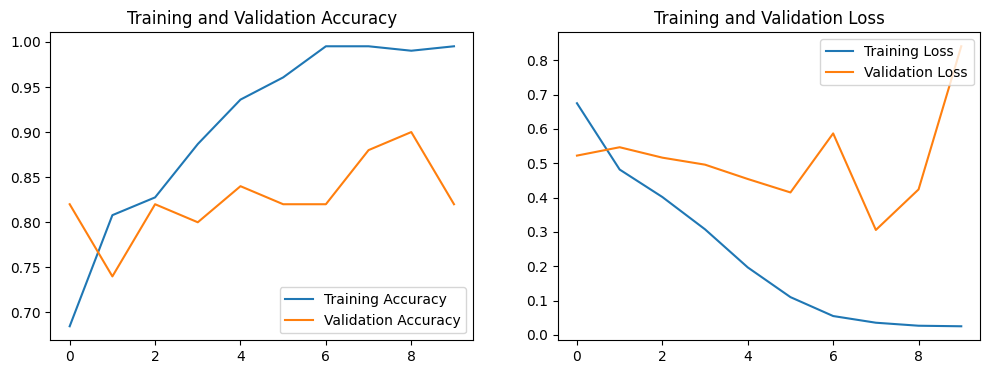

In [ ]:
# Visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step


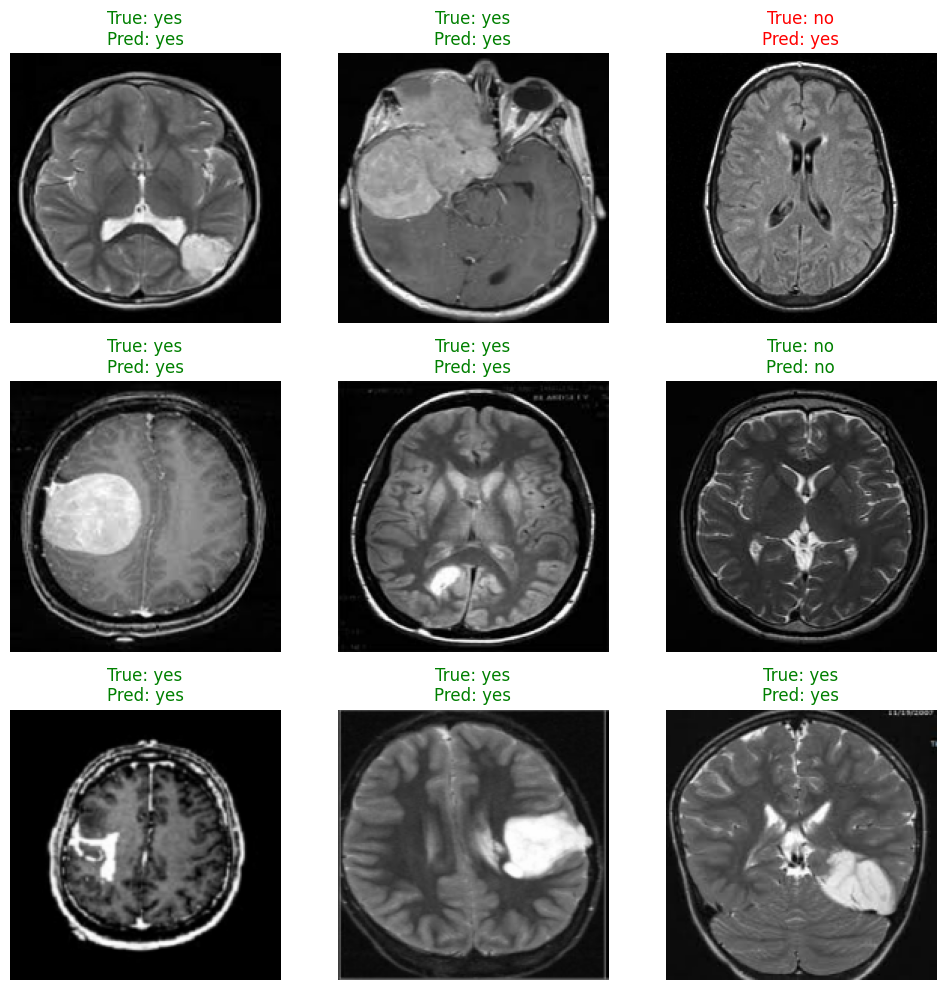

In [ ]:
# Make predictions on a batch of validation images

# Get a batch of images and labels from the validation set
for images, labels in val_ds.take(1):
    break # Take only one batch

predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 10))
for i in range(min(9, len(images))): # Display up to 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    true_label = class_names[labels[i]]
    pred_label = class_names[predicted_classes[i]]

    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Make Predictions on a New Image

This section allows you to upload a new image and use the trained CNN model to predict whether it belongs to the 'no' or 'yes' class.

Upload an image file (e.g., a 'no' or 'yes' image from your dataset):


Saving testy2.JPG to testy2 (1).JPG
User uploaded file 'testy2 (1).JPG'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

Prediction for 'testy2 (1).JPG':
Predicted Class: yes
Confidence: 0.9984


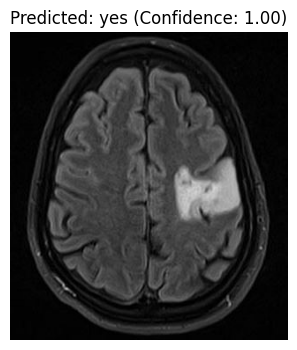

In [ ]:
from google.colab import files
from PIL import Image
import io

def preprocess_image(image_path):
    img = Image.open(image_path).resize((img_height, img_width))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    # The model's first layer is Rescaling(1./255), so we don't need to normalize here
    return img_array

print("Upload an image file (e.g., a 'no' or 'yes' image from your dataset):")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file '{fn}'")
    uploaded_image_path = io.BytesIO(uploaded[fn])
    # Preprocess the uploaded image
    processed_image = preprocess_image(uploaded_image_path)

    # Make a prediction
    prediction = model.predict(processed_image)
    predicted_class_index = np.argmax(prediction[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = prediction[0][predicted_class_index]

    print(f"\nPrediction for '{fn}':")
    print(f"Predicted Class: {predicted_class_name}")
    print(f"Confidence: {confidence:.4f}")

    # Display the uploaded image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(io.BytesIO(uploaded[fn])))
    plt.title(f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f})")
    plt.axis('off')
    plt.show()
